# 01 — Exploratory statistics and diagnostics

Section 2 (Statistical Foundations) of the Cross-Sectional Alpha Ranking project.

1. Raw data: stationarity and normality of prices vs. returns
2. Features: build and inspect
3. Stationarity of each feature (ADF + KPSS)
4. Cross-sectional and pooled distributions (skew, kurtosis, Jarque-Bera)
5. Winsorize + cross-sectional z-score
6. Multicollinearity (correlation, VIF)
7. Time-series vs cross-sectional z-score
8. Lookahead checklist
9. Label sanity and single-feature rank IC

In [1]:
import sys
from pathlib import Path

sys.path.append("../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

import diagnostics as d
from data import load
from features import FEATURES, build_features
from labels import make_labels, rebalance_dates
from models import ic_summary, rank_ic
from preprocess import preprocess

pd.set_option("display.precision", 3)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
BLUE, GRAY = "#2a6fdb", "#8c9099"

FIG = Path("../reports/figures")
FIG.mkdir(parents=True, exist_ok=True)


def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / f"{name}.png", dpi=150)

## 1. Raw data: prices vs. returns

In [2]:
px = load()
px["ret"] = np.log(px["close"]).groupby(px["ticker"]).diff()
print(px.shape, px["ticker"].nunique(), "tickers,", px["date"].min().date(), "to", px["date"].max().date())

(52160, 8) 20 tickers, 2014-06-02 to 2024-12-30


In [3]:
st_close = d.stationarity_table(px, "close")
st_ret = d.stationarity_table(px.dropna(subset=["ret"]), "ret")
pd.concat(
    {"close": st_close["verdict"].value_counts(), "log return": st_ret["verdict"].value_counts()},
    axis=1,
).fillna(0).astype(int)

d:\Finance\Cross-sectional-alpha-ranking\notebooks\../src\diagnostics.py:12: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_p = adfuller(s , autolag ="AIC")[1]
d:\Finance\Cross-sectional-alpha-ranking\notebooks\../src\diagnostics.py:15: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  kpss_p = kpss(s , regression="c" , nlags = "auto"

,close,log return
verdict,,
non-stationary,20,0
stationary,0,20


In [4]:
ret = px["ret"].dropna()
pd.DataFrame(d.normality(ret), index=["pooled daily log return"])

,skew,excess_kurtosis,jb,jb_p
pooled daily log return,-0.191,11.4,282657.681,0.0


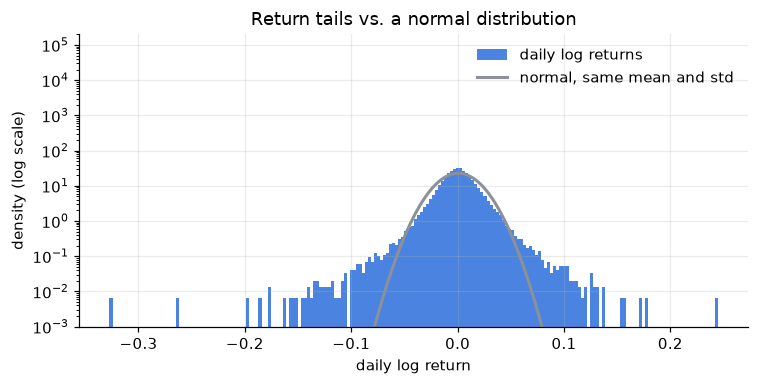

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(ret, bins=200, density=True, color=BLUE, alpha=0.85, label="daily log returns")
x = np.linspace(ret.min(), ret.max(), 400)
ax.plot(x, stats.norm.pdf(x, ret.mean(), ret.std()), color=GRAY, lw=2, label="normal, same mean and std")
ax.set_yscale("log")
ax.set_ylim(1e-3, None)
ax.set_xlabel("daily log return")
ax.set_ylabel("density (log scale)")
ax.set_title("Return tails vs. a normal distribution")
ax.legend(frameon=False)
save(fig, "returns_tails")

**To note for the report:** prices should come out non-stationary and returns stationary. KPSS p-values are clipped to the 0.01–0.10 range by statsmodels, so quote them as inequalities. Jarque-Bera will reject normality; the point is to document the fat tails.

## 2. Features

In [6]:
feats = build_features(px)
feats = feats[feats.index.get_level_values("date") >= "2015-01-01"].dropna()
flat = feats.reset_index()
print(feats.shape)
feats.describe().T

(49319, 7)


c:\Users\Eklavya\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,count,mean,std,min,25%,50%,75%,max
ret_5,49319.0,0.004,0.039,-0.393,-0.018,0.003,0.024,0.393
ret_20,49319.0,0.015,0.076,-0.585,-0.031,0.013,0.059,0.654
ret_60,49319.0,0.045,0.132,-0.624,-0.038,0.040,0.123,0.965
vol_20,49319.0,0.016,0.007,0.003,0.012,0.014,0.019,0.104
relvol_20,49319.0,-0.108,0.476,-3.237,-0.402,-0.136,0.160,2.805
rsi_14,49319.0,52.868,12.014,8.694,44.408,52.945,61.491,91.030
macd_norm,49319.0,0.003,0.020,-0.314,-0.007,0.005,0.015,0.080


## 3. Stationarity of each feature (per ticker, ADF + KPSS)

In [7]:
rows = []
for f in FEATURES:
    t = d.stationarity_table(flat, f)
    rows.append(t["verdict"].value_counts().rename(f))
pd.concat(rows, axis=1).fillna(0).astype(int).T

d:\Finance\Cross-sectional-alpha-ranking\notebooks\../src\diagnostics.py:12: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_p = adfuller(s , autolag ="AIC")[1]
d:\Finance\Cross-sectional-alpha-ranking\notebooks\../src\diagnostics.py:15: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  kpss_p = kpss(s , regression="c" , nlags = "auto"

verdict,stationary,ambiguous
ret_5,19,1
ret_20,19,1
ret_60,16,4
vol_20,7,13
relvol_20,20,0
rsi_14,13,7
macd_norm,18,2


Counts are tickers per verdict. Overlapping windows (the 60-day return, 20-day volatility) are serially correlated by construction; that affects standard errors, not the stationarity verdict.

## 4. Distributions: pooled and cross-sectional

In [8]:
norm_raw = d.normality_table(flat, FEATURES)
norm_raw

,skew,excess_kurtosis,jb,jb_p
ret_5,0.101,4.899,49394.243,0.000e+00
ret_20,-0.067,3.525,25566.065,0.000e+00
ret_60,0.175,1.773,6710.298,0.000e+00
vol_20,3.130,18.432,778700.123,0.000e+00
relvol_20,0.174,2.351,11606.715,0.000e+00
rsi_14,-0.055,-0.312,225.520,1.069e-49
macd_norm,-2.189,18.376,733289.623,0.000e+00


In [9]:
cs_rows = {}
for f in FEATURES:
    m = d.cross_sectional_moments(flat, f)
    cs_rows[f] = {
        "median_skew": m["skew"].median(),
        "p95_abs_skew": m["skew"].abs().quantile(0.95),
        "median_ex_kurt": m["excess_kurtosis"].median(),
        "p95_ex_kurt": m["excess_kurtosis"].quantile(0.95),
    }
pd.DataFrame(cs_rows).T

,median_skew,p95_abs_skew,median_ex_kurt,p95_ex_kurt
ret_5,0.190,1.825,0.320,5.215
ret_20,0.134,1.489,-0.010,3.409
ret_60,0.232,1.403,0.014,2.949
vol_20,0.699,2.145,0.374,6.069
relvol_20,0.354,1.659,0.393,4.205
rsi_14,0.033,1.105,-0.297,1.886
macd_norm,-0.155,1.441,-0.048,3.532


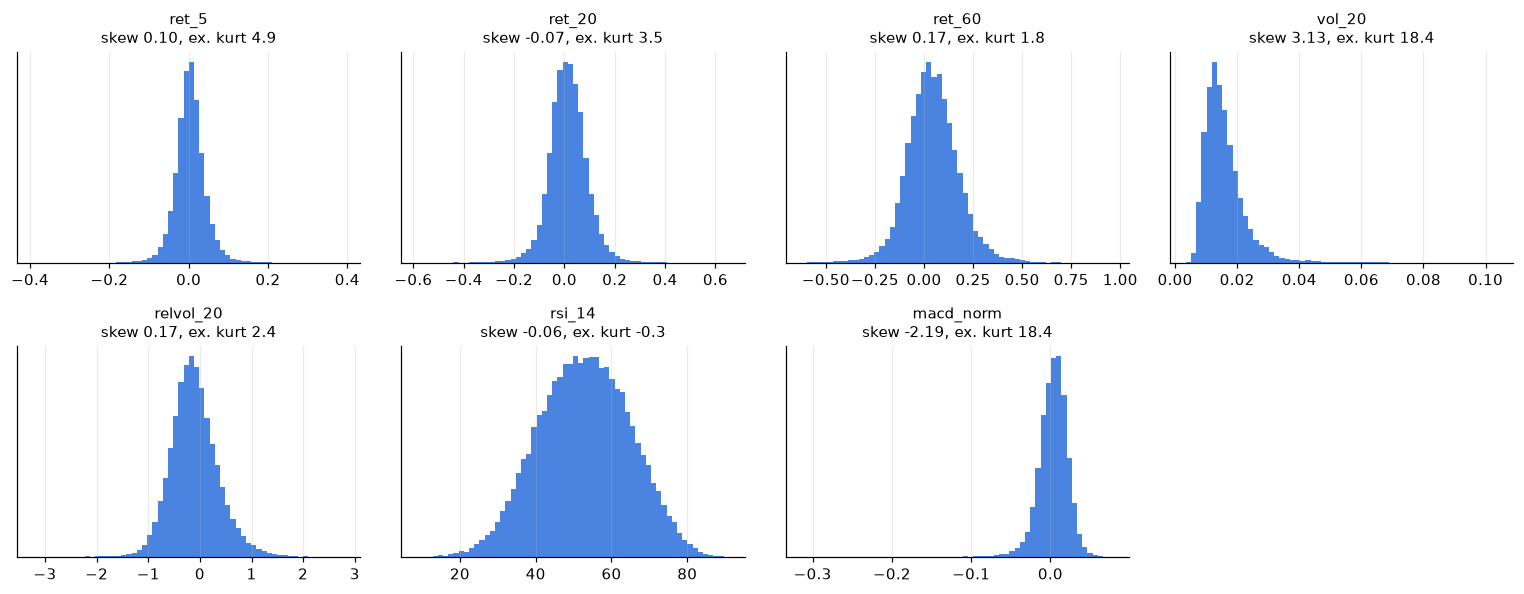

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(14, 5.5))
for ax, f in zip(axes.ravel(), FEATURES):
    ax.hist(flat[f], bins=60, color=BLUE, alpha=0.85)
    ax.set_title(f"{f}\nskew {flat[f].skew():.2f}, ex. kurt {flat[f].kurt():.1f}", fontsize=10)
    ax.set_yticks([])
axes.ravel()[-1].set_visible(False)
save(fig, "feature_distributions_raw")

## 5. Winsorize + cross-sectional z-score

In [11]:
z = preprocess(feats)
zf = z.reset_index()

g = z.groupby(level="date")
print("max |mean| per date:", g.mean().abs().max().max())
print("max |std - 1| per date:", (g.std() - 1).abs().max().max())

pd.concat(
    {
        "raw": norm_raw[["skew", "excess_kurtosis"]],
        "processed": d.normality_table(zf, FEATURES)[["skew", "excess_kurtosis"]],
    },
    axis=1,
)

max |mean| per date: 1.759703494030873e-15
max |std - 1| per date: 1.2212453270876722e-15


raw                 processed                
            skew excess_kurtosis      skew excess_kurtosis
ret_5      0.101           4.899     0.122          -0.687
ret_20    -0.067           3.525     0.109          -0.765
ret_60     0.175           1.773     0.160          -0.811
vol_20     3.130          18.432     0.390          -0.656
relvol_20  0.174           2.351     0.199          -0.667
rsi_14    -0.055          -0.312     0.030          -0.893
macd_norm -2.189          18.376    -0.028          -0.821

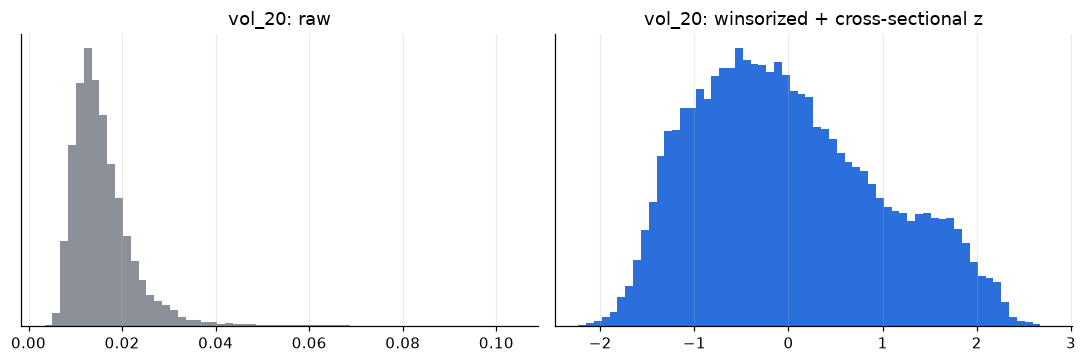

In [12]:
worst = norm_raw["excess_kurtosis"].idxmax()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].hist(flat[worst], bins=60, color=GRAY)
axes[0].set_title(f"{worst}: raw")
axes[1].hist(zf[worst], bins=60, color=BLUE)
axes[1].set_title(f"{worst}: winsorized + cross-sectional z")
for ax in axes:
    ax.set_yticks([])
save(fig, "winsorize_zscore_effect")

## 6. Multicollinearity

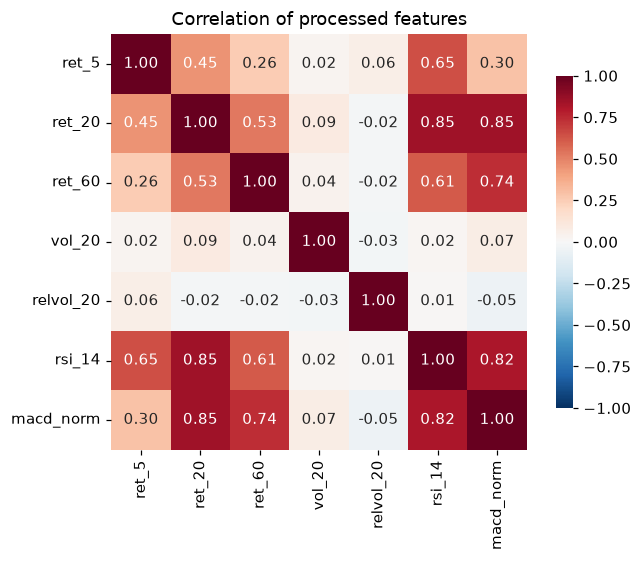

In [13]:
corr = z.corr()
fig, ax = plt.subplots(figsize=(6.5, 5.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.grid(False)
ax.set_title("Correlation of processed features")
save(fig, "feature_correlation")

In [14]:
vif = d.vif(zf, FEATURES)
vif.to_frame().assign(flag_above_5=vif > 5)

,vif,flag_above_5
ret_5,2.460,False
ret_20,5.497,True
ret_60,2.495,False
vol_20,1.031,False
relvol_20,1.012,False
rsi_14,7.738,True
macd_norm,8.146,True


**To note for the report:** which features overlap and why (the return horizons nest; RSI is close to a short-horizon return). This overlap is the reason Ridge is preferred over plain OLS for the linear model.

## 7. The standardisation trap: time-series vs. cross-sectional z-score

In [15]:
f = "ret_20"
ts_z = flat.groupby("ticker")[f].transform(
    lambda s: (s - s.rolling(252, min_periods=60).mean()) / s.rolling(252, min_periods=60).std()
)
pair = pd.DataFrame({"ts_z": ts_z, "cs_z": zf[f]}).dropna()
print(f"{f}: corr(ts_z, cs_z) = {pair.corr().iloc[0, 1]:.2f}; "
      f"sign disagreement = {(np.sign(pair['ts_z']) != np.sign(pair['cs_z'])).mean():.1%}")

ret_20: corr(ts_z, cs_z) = 0.71; sign disagreement = 21.9%


The two operations answer different questions: a stock against its own history, or against its peers on one date. This project uses only the cross-sectional version, guarded by tests in `tests/test_preprocess.py`.

## 8. Lookahead checklist

| Feature | Definition at date t | Information used | Check |
|---|---|---|---|
| `ret_5`, `ret_20`, `ret_60` | close(t) / close(t−k) − 1 | closes up to t | `tests/test_features.py::test_no_lookahead` |
| `vol_20` | std of last 20 daily log returns | closes up to t | same test |
| `relvol_20` | log(volume(t) / trailing 20-day mean volume) | volumes up to t | same test |
| `rsi_14` | Wilder-smoothed gains/losses, per ticker | closes up to t | same test |
| `macd_norm` | (EMA12 − EMA26) / close, per ticker | closes up to t | same test |
| z-score | per-date mean and std across stocks | same-date features only | `tests/test_preprocess.py::test_no_cross_date_leakage` |
| labels | close(next rebalance) / close(t) − 1 | used only as the target | `tests/test_labels.py` |
| training rows | rows with label_end ≤ prediction date | known by then | `tests/test_splits.py`, `tests/test_models.py::test_no_lookahead_in_training` |

**Known limitations**

- Yahoo adjusted closes are restated retroactively at every dividend or split, so a value computed today is not exactly what was visible on date t.
- The universe is today's index constituents, so the sample carries survivorship bias.
- Transaction costs and slippage are applied in the backtest, not here.

## 9. Label sanity and single-feature rank IC

In [16]:
rb = rebalance_dates(px["date"].unique())
labels = make_labels(px, rb)
ds = z[z.index.get_level_values("date").isin(rb)].join(labels, how="inner").dropna()
print(len(rb), "rebalance dates;", ds.shape[0], "labelled rows")
ds[["fwd_ret", "fwd_ret_z", "beat_median"]].describe().T

127 rebalance dates; 2380 labelled rows


,count,mean,std,min,25%,50%,75%,max
fwd_ret,2380.0,1.422e-02,0.077,-0.503,-0.034,0.012,0.059,0.483
fwd_ret_z,2380.0,-2.426e-18,0.975,-3.273,-0.659,-0.042,0.614,3.756
beat_median,2380.0,5.000e-01,0.500,0.000,0.000,0.500,1.000,1.000


In [17]:
rows = {}
for f in FEATURES:
    tmp = ds[[f, "fwd_ret"]].rename(columns={f: "score"})
    rows[f] = ic_summary(rank_ic(tmp))
pd.DataFrame(rows).T

,mean_ic,std_ic,ic_ir,t_stat,hit_rate,n_dates
ret_5,-0.060,0.236,-0.255,-2.778,0.378,119.0
ret_20,-0.063,0.252,-0.249,-2.713,0.370,119.0
ret_60,-0.039,0.280,-0.138,-1.508,0.437,119.0
vol_20,-0.031,0.233,-0.133,-1.454,0.429,119.0
relvol_20,-0.053,0.241,-0.220,-2.403,0.395,119.0
rsi_14,-0.079,0.272,-0.292,-3.189,0.395,119.0
macd_norm,-0.052,0.273,-0.190,-2.069,0.445,119.0


Each row is the per-month Spearman correlation between one feature and the next month's return, summarised over months. These are in-sample descriptive numbers, not results: they only show whether any feature carries obvious signal before modelling.